In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

In [3]:
train_path = r"C:\Users\Dell\Documents\Downloads\archive\Fruits Classification\train"

valid_path = r"C:\Users\Dell\Documents\Downloads\archive\Fruits Classification\valid"

test_path = r"C:\Users\Dell\Documents\Downloads\archive\Fruits Classification\test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 9700 images belonging to 5 classes.
Found 100 images belonging to 5 classes.
Found 200 images belonging to 5 classes.


In [6]:
class_names = list(train_generator.class_indices.keys())

print("Classes:")
print(class_names)

print("\nClass indices:")
print(train_generator.class_indices)

Classes:
['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']

Class indices:
{'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}


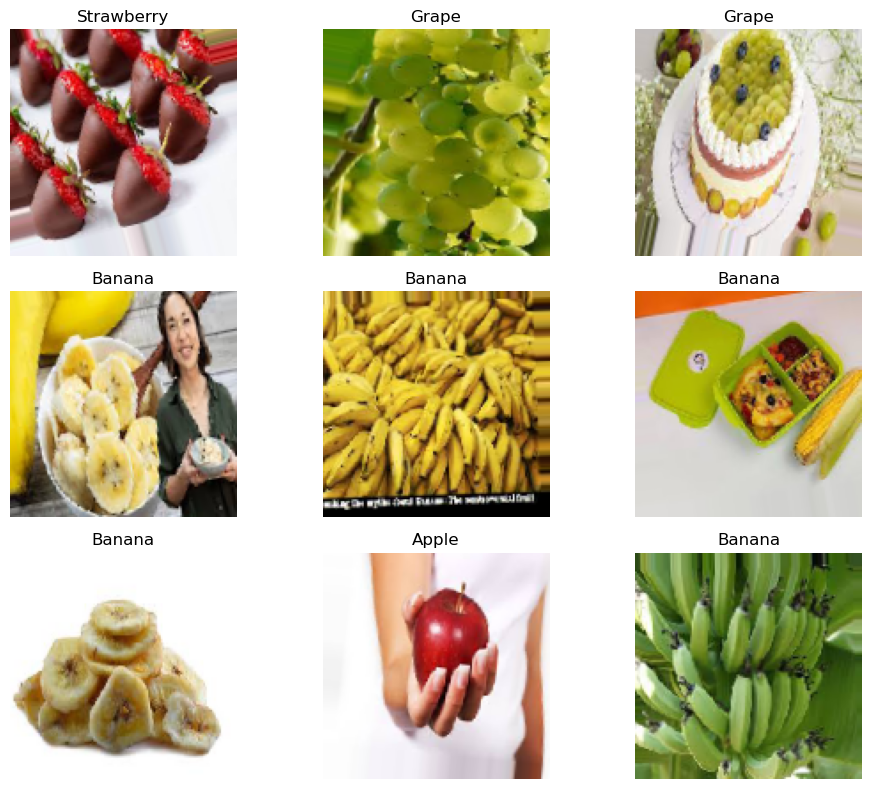

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    class_index = np.argmax(labels[i])

    plt.title(class_names[class_index])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15
)

Epoch 1/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 119s 385ms/step - accuracy: 0.4594 - loss: 1.2629 - val_accuracy: 0.5750 - val_loss: 1.1116
Epoch 2/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 120s 395ms/step - accuracy: 0.5539 - loss: 1.0772 - val_accuracy: 0.5900 - val_loss: 0.9924
Epoch 3/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 130s 428ms/step - accuracy: 0.5854 - loss: 1.0280 - val_accuracy: 0.6450 - val_loss: 0.9320
Epoch 4/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 136s 447ms/step - accuracy: 0.5948 - loss: 0.9973 - val_accuracy: 0.6350 - val_loss: 0.9392
Epoch 5/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 125s 412ms/step - accuracy: 0.6243 - loss: 0.9409 - val_accuracy: 0.6300 - val_loss: 0.8651
Epoch 6/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 157s 516ms/step - accuracy: 0.6403 - loss: 0.9230 - val_accuracy: 0.6800 - val_loss: 0.8995
Epoch 7/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 153s 503ms/step - accuracy: 0.6535 - loss: 0.8979 - val_accuracy: 0.6250 - val_loss: 0.8800
Epoch 8/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 131s 430ms/step - accuracy: 0.6609 -

In [24]:
# # 5. Final test
loss, accuracy = model.evaluate(test_generator)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.7200 - loss: 0.6774


In [25]:
model.save("fruit_classification_1.keras")